# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('pierce_county_house_sales.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(16814, 19)
sale_date                      object
sale_price                      int64
house_square_feet               int64
attic_finished_square_feet      int64
basement_square_feet            int64
attached_garage_square_feet     int64
detached_garage_square_feet     int64
fireplaces                      int64
hvac_description               object
exterior                       object
interior                       object
stories                         int64
roof_cover                     object
year_built                      int64
bedrooms                        int64
bathrooms                       int64
waterfront_type                object
view_quality                   object
utility_sewer                  object
dtype: object
sale_date                          0
sale_price                         0
house_square_feet                  0
attic_finished_square_feet         0
basement_square_feet               0
attached_garage_square_feet        0
detached_garage_square_feet   

In [3]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['age'] = df['sale_date'].dt.year - df['year_built']
df['waterfront_type'] = df['waterfront_type'].fillna('None')
df['view_quality'] = df['view_quality'].fillna('None')
df = df.dropna()
df = df[df['sale_price'] > 0]
df = df[df['house_square_feet'] > 0]
print(df.shape)
print(df.isnull().sum())

(16797, 20)
sale_date                      0
sale_price                     0
house_square_feet              0
attic_finished_square_feet     0
basement_square_feet           0
attached_garage_square_feet    0
detached_garage_square_feet    0
fireplaces                     0
hvac_description               0
exterior                       0
interior                       0
stories                        0
roof_cover                     0
year_built                     0
bedrooms                       0
bathrooms                      0
waterfront_type                0
view_quality                   0
utility_sewer                  0
age                            0
dtype: int64


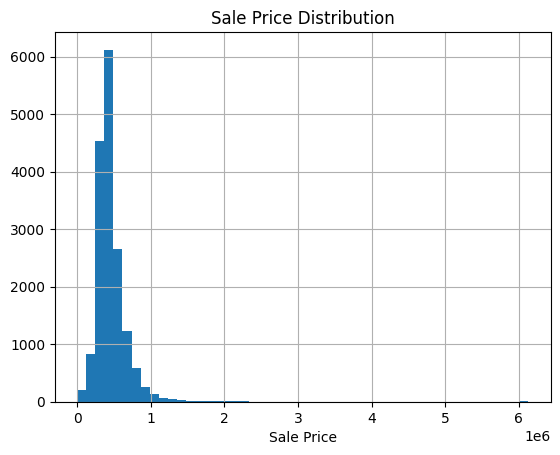

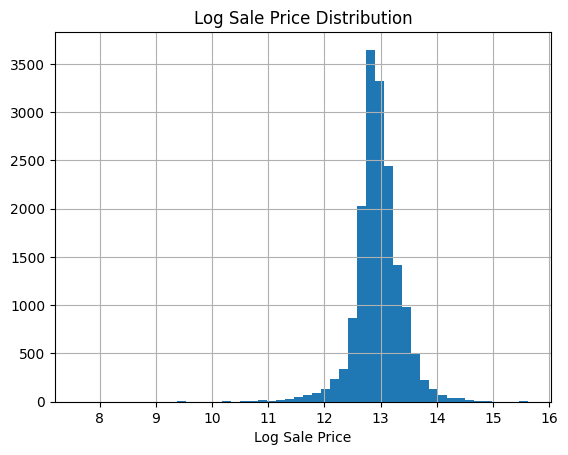

In [4]:
df['sale_price'].hist(bins=50)
plt.title('Sale Price Distribution')
plt.xlabel('Sale Price')
plt.show()

df['log_price'] = np.log(df['sale_price'])
df['log_price'].hist(bins=50)
plt.title('Log Sale Price Distribution')
plt.xlabel('Log Sale Price')
plt.show()

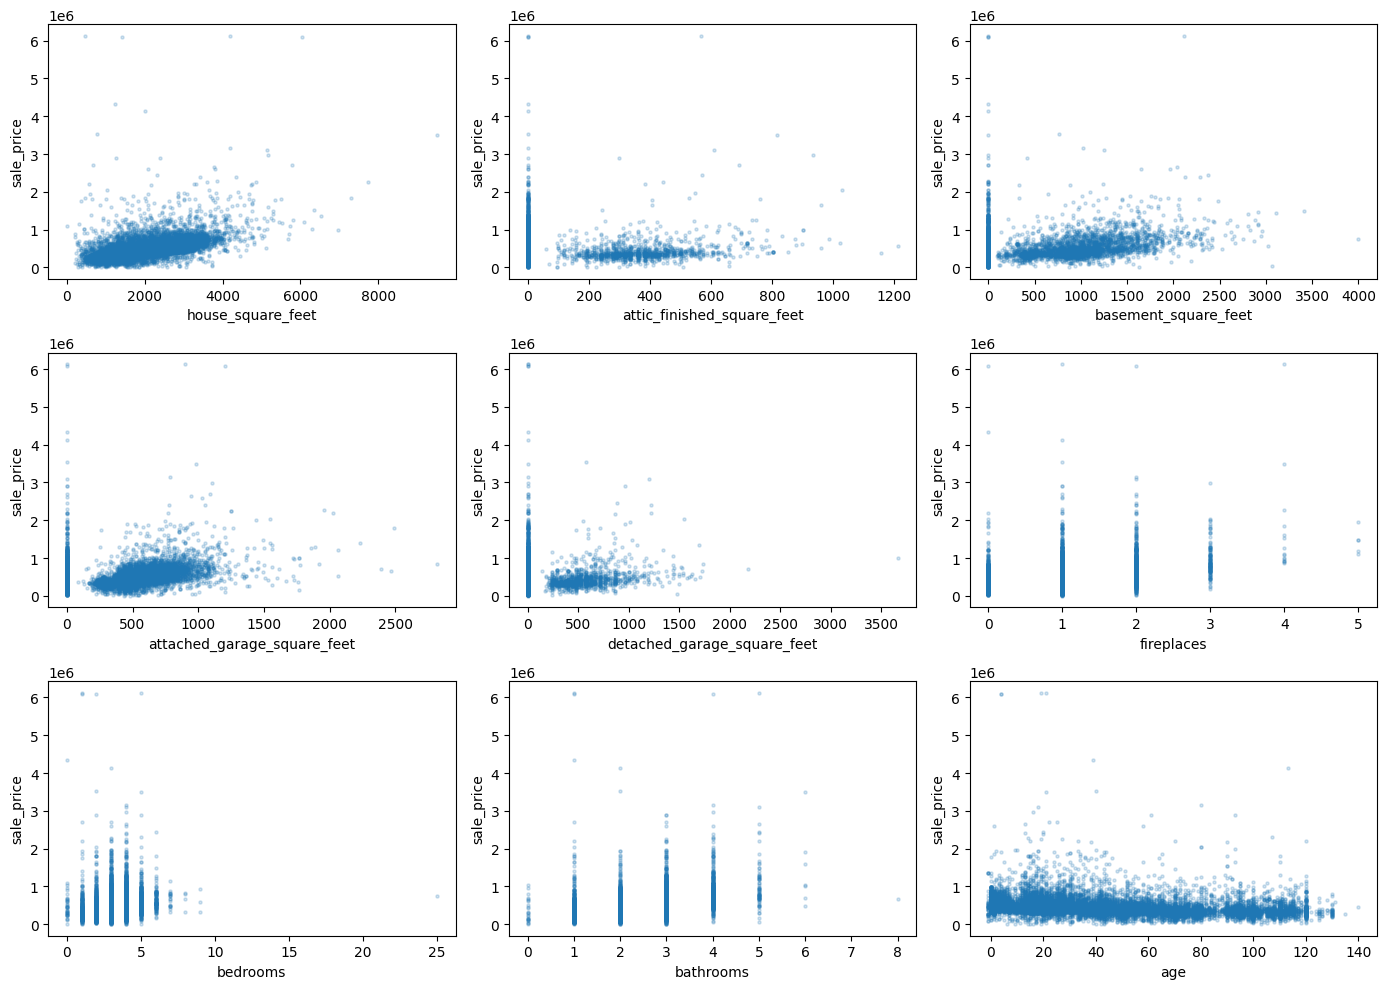

In [5]:
num_cols = ['house_square_feet', 'attic_finished_square_feet', 'basement_square_feet',
            'attached_garage_square_feet', 'detached_garage_square_feet',
            'fireplaces', 'bedrooms', 'bathrooms', 'age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.scatter(df[col], df['sale_price'], alpha=0.2, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('sale_price')
plt.tight_layout()
plt.show()

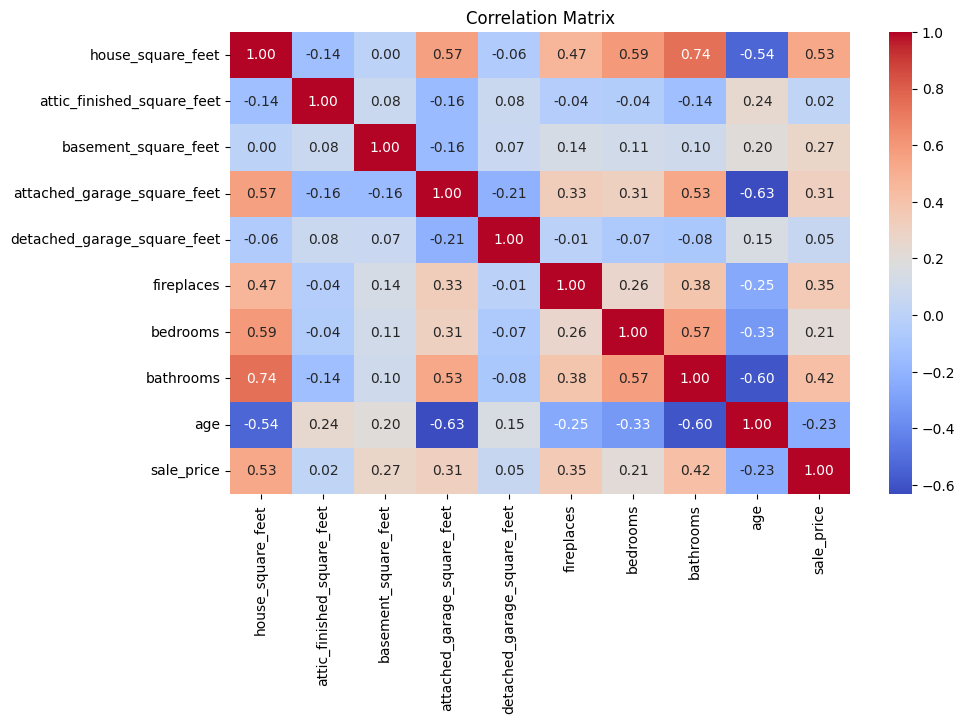

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols + ['sale_price']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [7]:
cat_cols = ['hvac_description', 'exterior', 'interior', 'roof_cover',
            'waterfront_type', 'view_quality', 'utility_sewer']

df['stories'] = df['stories'].astype(str)
cat_cols.append('stories')

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df_enc.shape)

(16797, 61)


In [8]:
from sklearn.model_selection import train_test_split

features = [c for c in df_enc.columns if c not in
            ['sale_price', 'log_price', 'sale_date', 'year_built']]

X = df_enc[features]
y = df_enc['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(13437, 57) (3360, 57)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    for split, X, y in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        pred = model.predict(X)
        rmse = root_mean_squared_error(y, pred)
        r2 = r2_score(y, pred)
        print(f"{name} | {split} | RMSE: {rmse:,.0f} | R²: {r2:.4f}")

sqft_cols = ['house_square_feet']
core_cols = ['house_square_feet', 'bedrooms', 'bathrooms', 'age', 'fireplaces']
all_num   = num_cols
cat_feature_cols = [c for c in df_enc.columns if c not in
                    ['sale_price', 'log_price', 'sale_date', 'year_built']]

evaluate(LinearRegression(), X_train[sqft_cols], y_train, X_test[sqft_cols], y_test, "Model 1: sqft only")
evaluate(LinearRegression(), X_train[core_cols], y_train, X_test[core_cols], y_test, "Model 2: core numeric")
evaluate(LinearRegression(), X_train[all_num],   y_train, X_test[all_num],   y_test, "Model 3: all numeric")
evaluate(LinearRegression(), X_train[cat_feature_cols], y_train, X_test[cat_feature_cols], y_test, "Model 4: numeric + categoricals")

Model 1: sqft only | Train | RMSE: 200,149 | R²: 0.2797
Model 1: sqft only | Test | RMSE: 190,957 | R²: 0.2964
Model 2: core numeric | Train | RMSE: 194,709 | R²: 0.3183
Model 2: core numeric | Test | RMSE: 184,457 | R²: 0.3435
Model 3: all numeric | Train | RMSE: 183,020 | R²: 0.3977
Model 3: all numeric | Test | RMSE: 171,185 | R²: 0.4346
Model 4: numeric + categoricals | Train | RMSE: 158,595 | R²: 0.5477
Model 4: numeric + categoricals | Test | RMSE: 159,897 | R²: 0.5067


Model 4 will be the best. The categorical variables capture more than just the numeric features do.

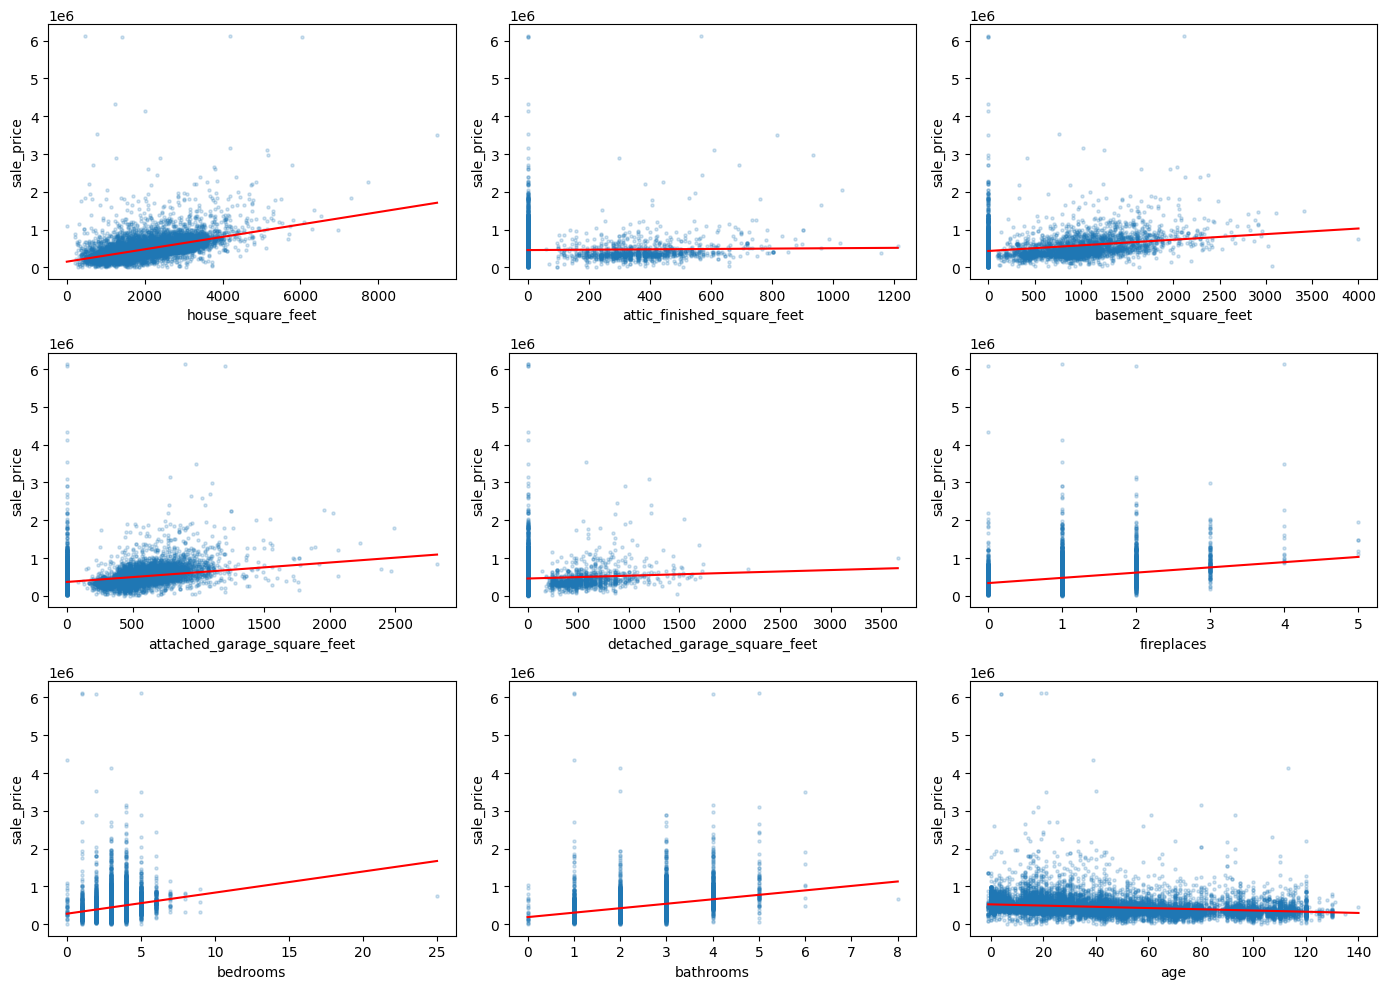

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.scatter(df[col], df['sale_price'], alpha=0.2, s=5)
    m, b = np.polyfit(df[col], df['sale_price'], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(xs, m*xs + b, color='red')
    ax.set_xlabel(col)
    ax.set_ylabel('sale_price')
plt.tight_layout()
plt.show()

Yes there are non-linearities in this.. It seems like bedrooms and bathroom, as well as fireplacec are all non-linear since they have curves with no clear line.

In [11]:
df_enc['age2'] = df_enc['age'] ** 2
df_enc['sqft_x_bath'] = df_enc['house_square_feet'] * df_enc['bathrooms']
df_enc['sqft_x_bed']  = df_enc['house_square_feet'] * df_enc['bedrooms']
df_enc['has_basement'] = (df_enc['basement_square_feet'] > 0).astype(int)
df_enc['has_attic']    = (df_enc['attic_finished_square_feet'] > 0).astype(int)
df_enc['has_det_garage'] = (df_enc['detached_garage_square_feet'] > 0).astype(int)

complex_features = [c for c in df_enc.columns if c not in
                    ['sale_price', 'log_price', 'sale_date', 'year_built']]

X2 = df_enc[complex_features]
y2 = df_enc['sale_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

evaluate(LinearRegression(), X2_train, y2_train, X2_test, y2_test, "Model 5: complex")

Model 5: complex | Train | RMSE: 157,118 | R²: 0.5561
Model 5: complex | Test | RMSE: 158,290 | R²: 0.5166


Since the plot showed the relationships are mostly linear, the transformation is not huge. Theres a little curvature, but the simple linear model was already a good enough fit.

The complex model barely improves over model 4. The RMSE drops super slightly and the R2 gains about 0.01.

I learned that feature selection matters more than model complexity. The largest improvement came from adding categorical variables in 4 than the math transformation. On overfitting and underfitting, models 1-3 are underfit since they leave out variables. I don't think we overfit here. On model selection, model 5's improvement does not make up for hte complexity it adds. I recommend going with mode l4.
Overall R2 of .51 is decent. Roughly half of variance in house prices is unexplained. This could be location, or other factors